In [22]:
import cv2
import numpy as np
import pims
import trackpy as tp
import matplotlib.pyplot as plt
import matplotlib  as mpl

from sklearn.neural_network import MLPClassifier

##Optionally, tweak styles.
mpl.rc('figure',  figsize=(20, 10))
mpl.rc('image', cmap='gray')

In [55]:
pre_median_size = 3
# define default size, minimum size, and circularity range for filters
DEFAULT_SIZE = 3
MIN_SIZE = 13
MIN_CIRCULARITY = 0.8
MAX_CIRCULARITY = 1.0

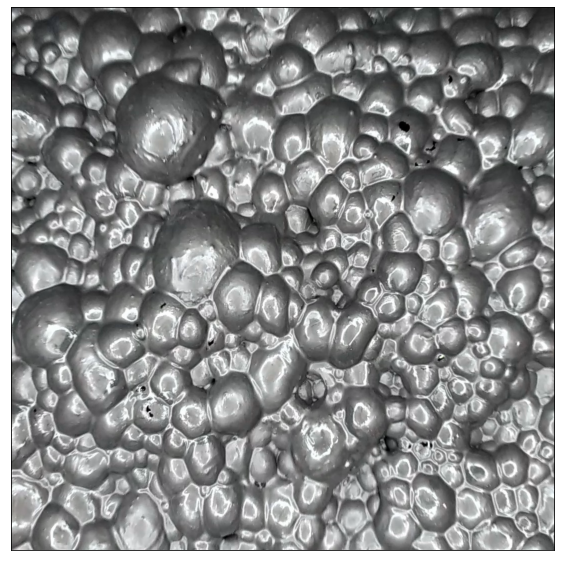

In [241]:
image = cv2.imread("/kaggle/working/rl4_pb8-7/frame4.jpg")

plt.imshow(image)
plt.xticks([]), plt.yticks([])  # to hide tick values on X and Y axis
plt.show()

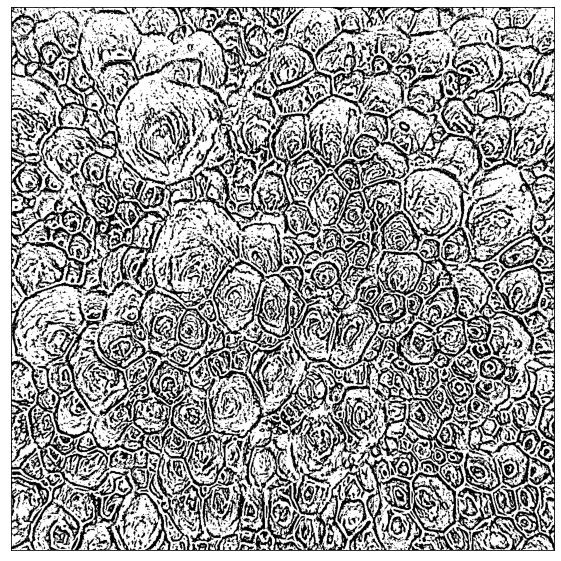

In [32]:
#transforming the image into gray scale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# apply median filter with given pre-median size
median = cv2.medianBlur(gray, pre_median_size)

# apply adaptive threshold
thresh = cv2.adaptiveThreshold(median, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)

plt.imshow(thresh)
plt.xticks([]), plt.yticks([])  # to hide tick values on X and Y axis
plt.show()

In [33]:
def is_round(contour):
    # compute circularity of contour
    (x, y), radius = cv2.minEnclosingCircle(contour)
    area = cv2.contourArea(contour)
    perimeter = cv2.arcLength(contour, True)
    circularity = (4 * np.pi * area) / ((perimeter * perimeter) + 1)

    # return True if circularity is within a certain range
    return circularity >= MIN_CIRCULARITY and circularity <= MAX_CIRCULARITY

In [56]:
# extract white spots by identifying round objects
contours, _ = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
white_spots = []
for contour in contours:
    if is_round(contour):
          white_spots.append(contour)

In [57]:
sizes = [spot.size for spot in white_spots]
print("Min size : ", min(sizes))
print("Max size : ", max(sizes))

Min size :  12
Max size :  36


In [58]:
# apply size filter to remove unwanted (very small) objects
white_spots = [spot for spot in white_spots if spot.size >= MIN_SIZE]

In [59]:
# compute mean size and number of white spots
mean_size = np.mean([spot.size for spot in white_spots])
num_spots = len(white_spots)

print("mean size : ", mean_size)
print("num_spots : ", num_spots)

mean size :  16.168389955686855
num_spots :  677


### In this section we will need to build a neural network classifier to determine forth type 

For the moment I didn't anotate images to train my neural network but we will assume that the network is trained and it will give us one of these three labels as an output : **"CLASS A to CLASS C"** 

In [ ]:
def classify_froth(image, pre_median_size):
    # process image and extract features
    mean_size, num_spots = process_image(image, pre_median_size)

    # use neural network classifier to determine froth type
    clf = MLPClassifier()
    clf.fit(X, y)
    froth_type = clf.predict([[mean_size, num_spots]])

    return froth_type

### After we get the froth_type using the neural network we proceede to the next step of updating the pre-median 

In [61]:
def update_pre_median_size(froth_type):
  # update pre-median size based on froth type
    if froth_type == 'CLASS A':
        pre_median_size = 3
    elif froth_type == 'CLASS B':
        pre_median_size = 5
    else:
        pre_median_size = 7

    return pre_median_size

In [70]:
# classify froth type and update pre-median size
froth_type = "CLASS C"
post_median_size = update_pre_median_size(froth_type)

7


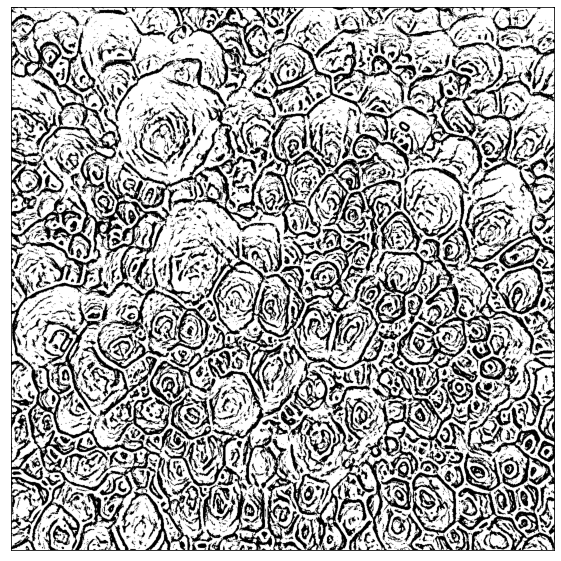

In [71]:
# process image with updated pre-median size

print(post_median_size)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
median = cv2.medianBlur(gray, post_median_size)
thresh = cv2.adaptiveThreshold(median, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)


plt.imshow(thresh)
plt.xticks([]), plt.yticks([])  # to hide tick values on X and Y axis
plt.show()

In [100]:
# extract first set of markers
_, markers1 = cv2.connectedComponents(thresh)

In [105]:
# extract second and third sets of markers using morphological operators
kernel = np.ones((5,5),np.uint8)
opening = cv2.morphologyEx(gray, cv2.MORPH_OPEN, kernel)
dilation = cv2.dilate(opening, kernel, iterations=2)
_, markers2 = cv2.connectedComponents(dilation)
erosion = cv2.erode(opening, kernel, iterations=2)
_, markers3 = cv2.connectedComponents(erosion)

In [233]:
# superimpose all sets of markers on topographic surface
topo = cv2.bitwise_not(gray)
post_median = cv2.medianBlur(topo, post_median_size)
markers = cv2.bitwise_or(markers1, markers2, markers3)

post_median = np.array(post_median)
markers = np.array(markers)

postB = np.copy(post_median)

for i in range(post_median.shape[0]):
    for j in range(post_median.shape[1]):
        postB[i][j] = markers[i][j]

superimposed = cv2.bitwise_or(post_median, postB)


In [232]:
# apply watershed transform to smoothed topographic surface
smoothed = cv2.GaussianBlur(superimposed, (5, 5), 0)
_, markers = cv2.connectedComponents(smoothed)
#labels = cv2.watershed(smoothed, markers)



In [ ]:
#---- Inverting the image here ----
img = cv2.bitwise_not(smoothed)
_, markers = cv2.connectedComponents(img)
print(img)


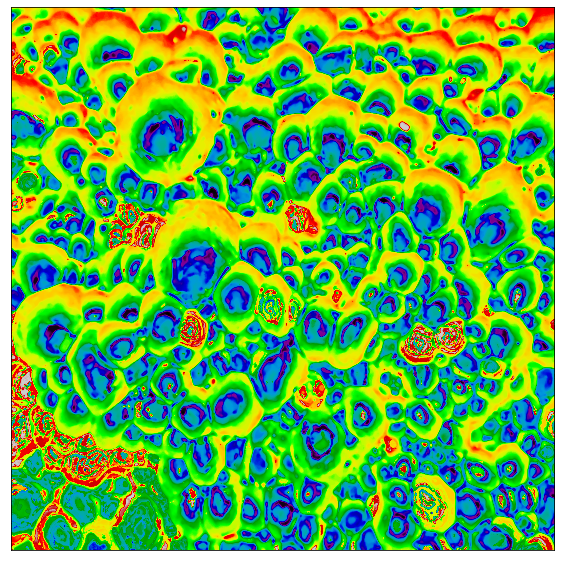

In [236]:
plt.imshow(superimposed, cmap='nipy_spectral')
plt.xticks([]), plt.yticks([])  # to hide tick values on X and Y axis
plt.show()

### Basic segs

In [256]:
from scipy import ndimage
from skimage.feature import peak_local_max
from skimage.segmentation import watershed

D = ndimage.distance_transform_edt(thresh)
localMax = peak_local_max(D, indices=False, min_distance=30,
	labels=thresh)

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:7: FutureWarning: indices argument is deprecated and will be removed in version 0.20. To avoid this warning, please do not use the indices argument. Please see peak_local_max documentation for more details.
  import sys


In [257]:
image = cv2.imread("/kaggle/working/rl4_pb8-7/frame4.jpg")


In [258]:
markers = ndimage.label(localMax, structure=np.ones((3, 3)))[0]
labels = watershed(-D, markers, mask=thresh)

In [152]:
import argparse
import imutils

In [259]:
# loop over the unique labels returned by the Watershed
# algorithm
for label in np.unique(labels):
	# if the label is zero, we are examining the 'background'
	# so simply ignore it
	if label == 0:
		continue
	# otherwise, allocate memory for the label region and draw
	# it on the mask
	mask = np.zeros(gray.shape, dtype="uint8")
	mask[labels == label] = 255
	# detect contours in the mask and grab the largest one
	cnts = cv2.findContours(mask.copy(), cv2.RETR_EXTERNAL,
		cv2.CHAIN_APPROX_SIMPLE)
	cnts = imutils.grab_contours(cnts)
	c = max(cnts, key=cv2.contourArea)
	# draw a circle enclosing the object
	((x, y), r) = cv2.minEnclosingCircle(c)
	cv2.circle(image, (int(x), int(y)), int(r), (0, 255, 0), 2)
	cv2.putText(image, "#{}".format(label), (int(x) - 10, int(y)),
		cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)


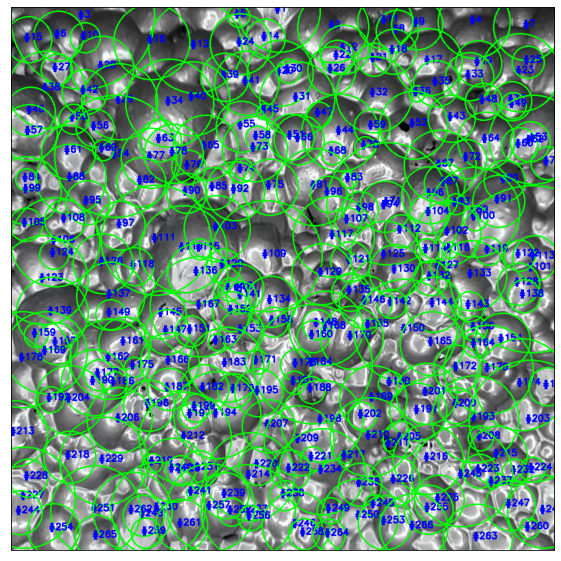

In [260]:
plt.imshow(image)
plt.xticks([]), plt.yticks([])  # to hide tick values on X and Y axis
plt.show()